# A/B Testing Analysis: Website Design Impact on User Engagement

"""
## Business Problem

An e-commerce company wants to test whether changing the website background
from White (Group A - Control) to Black (Group B - Treatment) improves user engagement
and conversion.

## Business Context

An e-commerce company is testing whether a change in website background 
(White → Black) impacts user behavior and conversion.

The goal is to determine whether the new design should be implemented 
to improve business performance.

## Objectives

1. Compare conversion rate between Group A and Group B
2. Analyze engagement using time spent and page views
3. Evaluate performance across device and location
4. Provide business recommendations based on findings
"""

In [18]:
import pandas as pd
import numpy as np

In [19]:
df = pd.read_csv(r"C:\Users\USER\OneDrive\a_b.csv")

In [20]:
df.head(10)

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,No,Mobile,Northern Ireland
1,11682,A,9,342,No,Mobile,Scotland
2,19825,A,2,396,No,Desktop,Northern Ireland
3,16080,B,4,318,No,Desktop,Wales
4,18851,A,1,338,Yes,Desktop,Scotland
5,13134,B,2,93,No,Desktop,Scotland
6,16702,A,5,106,No,Mobile,Northern Ireland
7,10041,B,9,292,No,Mobile,Northern Ireland
8,13191,B,8,434,No,Desktop,Northern Ireland
9,14427,B,12,271,No,Desktop,England


## Data Understanding

The dataset contains user-level interaction data including:
- Group (A: Control, B: Treatment)
- Conversion (Yes/No)
- Time Spent
- Page Views
- Device and Location

Conversion is the key business metric representing whether a user completed a desired action.

In [21]:
df.info()
df.describe()
df['Group'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   User ID     5000 non-null   int64 
 1   Group       5000 non-null   object
 2   Page Views  5000 non-null   int64 
 3   Time Spent  5000 non-null   int64 
 4   Conversion  5000 non-null   object
 5   Device      5000 non-null   object
 6   Location    5000 non-null   object
dtypes: int64(3), object(4)
memory usage: 273.6+ KB


Group
A    2519
B    2481
Name: count, dtype: int64

In [22]:
# Convert Conversion to numeric
df['Conversion'] = df['Conversion'].map({'Yes': 1, 'No': 0})

# Check missing values
df.isnull().sum()

User ID       0
Group         0
Page Views    0
Time Spent    0
Conversion    0
Device        0
Location      0
dtype: int64

In [23]:
df.head()

,User ID,Group,Page Views,Time Spent,Conversion,Device,Location
0,14292,B,3,424,0,Mobile,Northern Ireland
1,11682,A,9,342,0,Mobile,Scotland
2,19825,A,2,396,0,Desktop,Northern Ireland
3,16080,B,4,318,0,Desktop,Wales
4,18851,A,1,338,1,Desktop,Scotland


## Key Metrics Definition

- Conversion Rate → % of users who completed the desired action  
- Time Spent → Measures engagement duration  
- Page Views → Indicates content exploration  

These metrics help evaluate both business impact (conversion) and user behavior (engagement).

## Conversion Rate Comparison

We compare conversion rates between control (A) and treatment (B) groups.

In [24]:
conversion_rate = df.groupby('Group')['Conversion'].mean() * 100
conversion_rate

Group
A     5.398968
B    14.066909
Name: Conversion, dtype: float64

Observation:
Group B shows a significantly higher conversion rate compared to Group A.

In [25]:
#Average Time Spent
df.groupby('Group')['Time Spent'].mean()

Group
A    241.733227
B    243.303910
Name: Time Spent, dtype: float64

Observation:
Time spent between groups is very similar, indicating no strong difference in engagement duration.

In [26]:
#Average Page Views
df.groupby('Group')['Page Views'].mean()

Group
A    7.581580
B    7.492946
Name: Page Views, dtype: float64

In [28]:
conversion_summary = df.groupby('Group')['Conversion'].mean().reset_index()

conversion_summary['Conversion Rate (%)'] = (conversion_summary['Conversion'] * 100).round(2)

conversion_summary[['Group', 'Conversion Rate (%)']]

,Group,Conversion Rate (%)
0,A,5.40
1,B,14.07


In [32]:
#By_Devicw
df.groupby(['Device', 'Group'])['Conversion'].mean().unstack() * 100

Group,A,B
Device,,
Desktop,5.868167,13.910355
Mobile,4.941176,14.237574


In [33]:
#By_Location
df.groupby(['Location', 'Group'])['Conversion'].mean().unstack() * 100

Group,A,B
Location,,
England,6.930693,14.687500
Northern Ireland,5.048860,11.464968
Scotland,4.925373,15.057283
Wales,4.769475,15.116279


In [35]:
from scipy.stats import ttest_ind

group_a = df[df['Group'] == 'A']['Time Spent']
group_b = df[df['Group'] == 'B']['Time Spent']

ttest_ind(group_a, group_b)

TtestResult(statistic=np.float64(-0.46954858146462514), pvalue=np.float64(0.6386980515632602), df=np.float64(4998.0))

## Statistical Testing

A t-test was conducted to evaluate whether the difference in time spent 
between Group A and Group B is statistically significant.

Result:
p-value = 0.638 (> 0.05)

Interpretation:
The difference is not statistically significant.

Conclusion:
There is no strong evidence that the new design impacts user engagement 
in terms of time spent.

In [36]:
device_conversion = (
    df.groupby(['Device', 'Group'])['Conversion']
    .mean()
    .reset_index()
)

# Convert to percentage
device_conversion['Conversion Rate (%)'] = (device_conversion['Conversion'] * 100).round(2)

device_conversion

,Device,Group,Conversion,Conversion Rate (%)
0,Desktop,A,0.058682,5.87
1,Desktop,B,0.139104,13.91
2,Mobile,A,0.049412,4.94
3,Mobile,B,0.142376,14.24


The increase in conversion rate for Group B is consistent across both 
Desktop and Mobile devices, indicating that the design change has a 
broad impact rather than being limited to a specific user segment.

In [37]:
pivot_df = device_conversion.pivot(index='Device', columns='Group', values='Conversion Rate (%)')
pivot_df

Group,A,B
Device,,
Desktop,5.87,13.91
Mobile,4.94,14.24


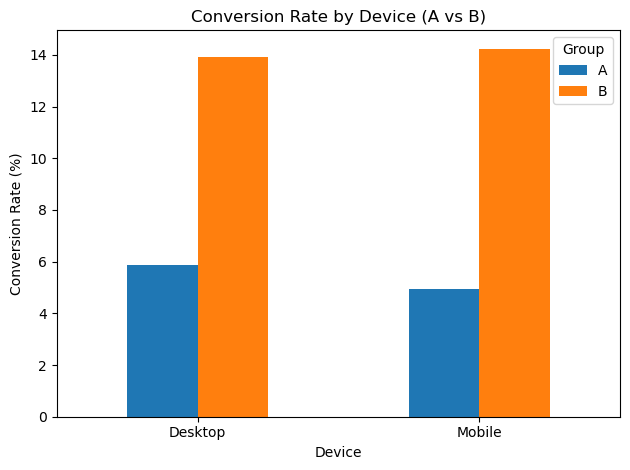

In [38]:
import matplotlib.pyplot as plt

pivot_df.plot(kind='bar')

plt.title('Conversion Rate by Device (A vs B)')
plt.xlabel('Device')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Group')

plt.tight_layout()
plt.show()

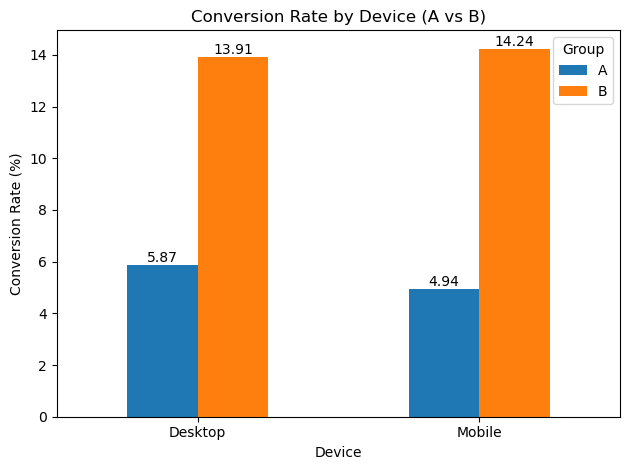

In [39]:
ax = pivot_df.plot(kind='bar')

for container in ax.containers:
    ax.bar_label(container, fmt='%.2f')

plt.title('Conversion Rate by Device (A vs B)')
plt.xlabel('Device')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=0)
plt.legend(title='Group')

plt.tight_layout()
plt.show()

## Key Insights

1. Group B significantly increases conversion rate (5.39% → 14.07%)

2. Time spent shows no statistically significant difference between groups

3. Page views slightly decrease in Group B, suggesting users may convert faster

4. Conversion improvement is consistent across devices and locations

## Recommendations

1. The new design (Group B) shows strong improvement in conversion rate.

2. However, due to lack of full statistical validation and dataset limitations,
   the results should be treated as directional.

3. It is recommended to conduct a controlled experiment before full rollout.

## Limitations

- The dataset is synthetic and may not reflect real-world behavior  
- Statistical testing was limited and not applied to all metrics  
- No control over experiment design (sample size, randomization)  
- Behavioral interpretations are assumptions, not proven  

Therefore, results should be treated as exploratory.